# AthenaK Dust Module: Shearing-Box Tests

*(formerly `phase2_validation.ipynb`)* — validates the dust module in rotating
(shearing-box) configurations: NSH drift equilibrium and the streaming-instability
linA/linB eigenmode ladders. The two
headline tests are **axisymmetric (2-D r–z)** and run with the standard machinery — no
shear-periodic communication is needed because the shear lies in the untracked azimuthal
direction:

| # | Test | Property verified | Result |
|---|------|-------------------|--------|
| 1 | Multi-species NSH drift equilibrium (2-D r–z, 10 orbits) | rotation + radial forcing + drag composed **unsplit** in the IMEX stages | held to **round-off** (~1e-16) |
| 2 | Streaming instability linA/linB (2-D r–z, Youdin & Johansen 2007 modes, 16–64 cells/wavelength) | full drag–pressure–rotation coupling of perturbations | growth rates converge with resolution to the analytic values, matching/beating Athena-PPM (BS10) |
| 3 | 3-D shear-periodic machinery (particle wrap + routing maps + $u^*$ remap) | plumbing for full 3-D boxes | serial **and MPI** validated (sendlist fix, §4) |

Two hard-won practical requirements for streaming-instability runs (§3):
`rsolver = roe` (HLLE's diffusivity destroys the modes) and `cfl_number ≤ 0.45`
(the imex2+ explicit stage advances fluxes by $\gamma\Delta t \approx 1.71\Delta t$).

## Test setup

### Problem generators

The NSH test uses the built-in `dust_nsh` generator in
`athenak/src/pgen/tests/dust_nsh.cpp`. The linA/linB ladders use `streaming_linear` in
`athenak/src/pgen/tests/streaming_linear.cpp`. AthenaK is compiled with
`-DPROBLEM=built_in_pgens`; each input chooses its generator through `<problem>/pgen_name`.

### CPU builds

From the directory containing both `athenak/` and `athenak_dust_tests/`:

```bash
cmake -S athenak -B athenak/build \
  -DCMAKE_BUILD_TYPE=Release \
  -DPROBLEM=built_in_pgens
cmake --build athenak/build -j
```

The notebook performs this serial build if needed. Optional multi-rank experiments use a separate
`athenak/build-mpi` configured with `-DAthena_ENABLE_MPI=ON`. Use the `mpirun` belonging to that
MPI toolchain; if it is not on `PATH`, set the `MPIRUN` environment variable to its executable path
before starting Jupyter. The notebook's default ladder remains serial for reproducibility.

### Inputs and execution

Tracked reference inputs are stored at:

```text
athenak_dust_tests/inputs/dust_nsh.athinput
athenak_dust_tests/inputs/streaming_linA_128.athinput
athenak_dust_tests/inputs/streaming_linB_128.athinput
```

The NSH file is used directly. For the resolution ladders, the notebook independently solves the
eigenproblem and writes complete runtime inputs under `athenak/build/run-dust/`; the two tracked
streaming files preserve the validated 128-cpw configurations. Start Jupyter from the directory
containing both repositories, open this notebook, and select **Run All**. Existing histories are
reused; set `RERUN_ALL = True` to regenerate them. The full serial ladder takes roughly ten minutes,
depending on the CPU. At 128 cpw with PPMX, retain the validated conservative CFL of **0.225**.

In [1]:
import os, shutil, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT/'athenak').is_dir() and (ROOT/'athenak_cc'/'athenak').is_dir():
    ROOT = ROOT/'athenak_cc'
assert (ROOT/'athenak').is_dir() and (ROOT/'athenak_dust_tests').is_dir(), \
    'start Jupyter from the directory containing athenak/ and athenak_dust_tests/, or its parent'
ATHENA = ROOT/'athenak/build/src/athena'          # serial build (small runs)
ATHENA_MPI = ROOT/'athenak/build-mpi/src/athena'  # MPI build (128-cpw rungs)
MPIRUN = os.environ.get('MPIRUN') or shutil.which('mpirun') or 'mpirun'
TEST_INPUTS = ROOT/'athenak_dust_tests/inputs'
WORK = ROOT/'athenak/build/run-dust'   # shared with earlier sessions to reuse SI runs
WORK.mkdir(parents=True, exist_ok=True)
if not ATHENA.exists():
    subprocess.run(['cmake','-S',str(ROOT/'athenak'),'-B',str(ROOT/'athenak/build'),
                    '-DCMAKE_BUILD_TYPE=Release','-DPROBLEM=built_in_pgens'], check=True)
    subprocess.run(['cmake','--build',str(ROOT/'athenak/build'),'-j8'], check=True)

RERUN_ALL = False       # force re-running the SI ladder even if history files exist

def run_athena(inputfile, *overrides, np=1):
    # mpirun requires absolute exe/input paths; user-history sums are MPI-reduced
    if np > 1:
        cmd = [MPIRUN, '-np', str(np), str(ATHENA_MPI), '-i', str(inputfile)]
    else:
        cmd = [str(ATHENA), '-i', str(inputfile)]
    res = subprocess.run(cmd + list(overrides),
                         cwd=WORK, capture_output=True, text=True)
    if res.returncode != 0:
        print(res.stdout[-2000:]); print(res.stderr[-1000:])
        raise RuntimeError(f'athena failed: {inputfile}')
    return res

def verdict(ok, msg):
    print(('PASS  ' if ok else '*** FAIL ***  ') + msg)
    return ok
print('setup complete')

setup complete


## 1. Multi-species NSH drift equilibrium — held to round-off

Gas + three dust species ($t_s = 0.01, 0.1, 1.0$; $\epsilon = 0.2, 0.5, 0.3$) in an
unstratified 2-D r–z shearing box. The gas feels the radial pressure-gradient mimic
$a_x = 2\Omega\,\eta v_K$ through the standard `const_accel` source term (dust does not),
and the system is initialized at the exact steady drift solution of the
$(2+2N)\times(2+2N)$ linear system (solved identically in the problem generator and
below). Because the rotation/forcing kicks and the implicit drag solve are composed
unsplit inside the IMEX stages, **the continuum equilibrium is an exact fixed point of
the discrete update**: after 10 orbits (~4500 cycles, with every species drifting
radially through the periodic boundaries), all deviations must sit at round-off.
Any Strang-like splitting error would appear as secular drift — this is the analogue of
the steady-drift test in Krapp et al. (2024) §3.6.

In [2]:
(WORK/'dust_nsh-errs.dat').unlink(missing_ok=True)
run_athena(TEST_INPUTS/'dust_nsh.athinput')
E = np.atleast_2d(np.loadtxt(WORK/'dust_nsh-errs.dat'))[0]
print('cycles:', int(E[3]))
print(f'gas errors:      |d u_x| = {E[4]:.2e}   |d u_phi| = {E[5]:.2e}')
for s in range(3):
    print(f'species {s+1} errors: |d v_x| = {E[6+2*s]:.2e}   |d v_phi| = {E[7+2*s]:.2e}')
ok = verdict(np.all(E[4:] < 1e-13), 'NSH equilibrium held to round-off over 10 orbits')
print('\nreference (2026-07-14): all components 1e-16 to 1e-17')

cycles: 4495
gas errors:      |d u_x| = 1.32e-16   |d u_phi| = 6.25e-17
species 1 errors: |d v_x| = 6.94e-17   |d v_phi| = 5.90e-17
species 2 errors: |d v_x| = 1.22e-16   |d v_phi| = 2.43e-17
species 3 errors: |d v_x| = 9.37e-17   |d v_phi| = 4.34e-17
PASS  NSH equilibrium held to round-off over 10 orbits

reference (2026-07-14): all components 1e-16 to 1e-17


## 2. Streaming instability: linA and linB growth rates (2-D r–z)

The classic axisymmetric eigenmode tests (Youdin & Goodman 2005; Youdin & Johansen 2007;
Yang & Johansen 2016 §4.2; Bai & Stone 2010 §4.3). Both use $\tau_s = 0.1$ and
$a_x = 0.1\,c_s\Omega$ ($\eta v_K = 0.05\,c_s$):

| mode | $K_x = K_z$ | $\epsilon_0$ | published $s/\Omega$ (YJ07) | this system's target |
|------|-----|-----|-------|-------|
| linA | 30 | 3.0 | 0.4190204 | **0.4190091** |
| linB | 6 | 0.2 | 0.0154764 | **0.0154862** |

The full $8\times8$ eigenproblem is solved below; the eigenvector matches YJ07's
published table to $\le5\times10^{-6}$ per component. Our radial-orientation
convention is the exact $k_x$-mirror of YJ07's ($\omega_{\rm re}$ sign flips,
verified identical $s$ under $K_x\to-K_x$), and our linearized system carries a real
$\sim10^{-5}$ eigenvalue offset from the published values (background-force term
treated differently; ours is term-consistent with the code's `const_accel` model) —
the "this system's target" column (40-digit arithmetic) is the correct reference.
The eigenpair is selected by min$|\omega-\omega_{\rm ref}|$: `np.linalg.eig` on this
strongly non-normal matrix carries $\sim10^{-5}$ eigenvalue noise across BLAS
environments, which can otherwise flip the selection.

Runs use **`ppmx` reconstruction (`nghost=3`)** — the earlier PLM ladder
(0.143/0.322/0.405 for linA) was marginal-resolution PLM behavior, not a module
defect. Growth is measured from the $(k_x,k_z)$ Fourier projection of the particle
mass distribution with an **early-window fit** ($t\in[3,9]$ for linA, $t\in[0,6]$
for linB, classic-Athena practice): at high resolution, fast parasitic SI modes
(round-off-seeded, $s\sim0.3$–$0.45\Omega$ for linB parameters, bit-sensitive
takeover time) can overtake the slow fundamental at late times, which invalidated
this notebook's original long-window linB fits.

**CFL caveat discovered while adding the 128-cpw rungs (2026-07-16)**: at 128 cpw
with `ppmx`, cfl = 0.45 excites a **numerical** grid-scale instability of the coupled
ppmx+drag update growing at $\sim4.5\Omega$ — 5× faster than the fastest *physical*
SI mode for linA parameters ($0.86\Omega$, from scanning the eigensystem over the
whole resolvable K-plane). Diagnostics: identical in serial and MPI; absent with plm
at the same decomposition; present on a single block (not a boundary/halo issue);
absent for pure hydro (`back_reaction=false`); **eliminated at cfl = 0.225** (the run
then tracks the clean mode to 3 digits). The 128-cpw rungs therefore run at
cfl = 0.225; 16–64 cpw are verified clean at 0.45 (linB to $t=40$).

In [3]:
def nsh_drift(Om, q, ax, eps, taus):
    """multi-species NSH drift (same linear system as SolveNSH in the pgens)"""
    ns = len(eps); n = 2 + 2*ns
    A = np.zeros((n,n)); b = np.zeros(n)
    A[0,1] = 2*Om
    for s in range(ns):
        A[0,0] -= eps[s]/taus[s]; A[0,2+2*s] += eps[s]/taus[s]
    b[0] = -ax
    A[1,0] = -(2-q)*Om
    for s in range(ns):
        A[1,1] -= eps[s]/taus[s]; A[1,3+2*s] += eps[s]/taus[s]
    for s in range(ns):
        rx, rp = 2+2*s, 3+2*s
        A[rx,rp] = 2*Om;      A[rx,rx] -= 1/taus[s]; A[rx,0] += 1/taus[s]
        A[rp,rx] = -(2-q)*Om; A[rp,rp] -= 1/taus[s]; A[rp,1] += 1/taus[s]
    x = np.linalg.solve(A,b)
    return x[0], x[1], x[2], x[3]

# this system's growing modes, 40-digit-arithmetic references (kx-mirror of YJ07)
WREF_A = 0.3480182 + 0.4190091j
WREF_B = -0.4998788 + 0.0154862j

def si_eigen(Kx, Kz, taus, eps, w_ref, etavk=0.05, Om=1.0, cs=1.0, q=1.5):
    """Axisymmetric SI eigenproblem; unknowns [Dg,ux,uy,uz,Dp,vx,vy,vz],
    perturbations ~ exp(i(kx x + kz z) - i w t) in the shear-relative frame.
    The eigenpair is pinned by distance to w_ref (NOT argmax growth; see above)."""
    kx = Kx*Om/etavk; kz = Kz*Om/etavk
    Ux, Uy, Vx, Vy = nsh_drift(Om, q, 2*Om*etavk, [eps], [taus])
    ts = taus/Om
    A = np.zeros((8,8), dtype=complex)
    A[0,0]=kx*Ux; A[0,1]=kx; A[0,3]=kz
    A[1,1]=kx*Ux + 1j*(-eps/ts); A[1,2]=1j*2*Om
    A[1,0]=kx*cs**2 + 1j*(-(eps/ts)*(Vx-Ux)); A[1,4]=1j*((eps/ts)*(Vx-Ux)); A[1,5]=1j*(eps/ts)
    A[2,2]=kx*Ux + 1j*(-eps/ts); A[2,1]=1j*(-(2-q)*Om)
    A[2,0]=1j*(-(eps/ts)*(Vy-Uy)); A[2,4]=1j*((eps/ts)*(Vy-Uy)); A[2,6]=1j*(eps/ts)
    A[3,3]=kx*Ux + 1j*(-eps/ts); A[3,0]=kz*cs**2; A[3,7]=1j*(eps/ts)
    A[4,4]=kx*Vx; A[4,5]=kx; A[4,7]=kz
    A[5,5]=kx*Vx + 1j*(-1/ts); A[5,6]=1j*2*Om; A[5,1]=1j*(1/ts)
    A[6,6]=kx*Vx + 1j*(-1/ts); A[6,5]=1j*(-(2-q)*Om); A[6,2]=1j*(1/ts)
    A[7,7]=kx*Vx + 1j*(-1/ts); A[7,3]=1j*(1/ts)
    w, V = np.linalg.eig(A)
    i = int(np.argmin(np.abs(w - w_ref)))
    return w[i], V[:,i], (Ux, Uy, Vx, Vy, kx, kz)

wA, vA, bgA = si_eigen(30, 30, 0.1, 3.0, WREF_A)
wB, vB, bgB = si_eigen(6, 6, 0.1, 0.2, WREF_B)
print(f'linA: omega = {wA:.7f}   (this system: {WREF_A}; YJ07 kx-mirror: -0.3480127+0.4190204i)')
print(f'linB: omega = {wB:.7f}   (this system: {WREF_B}; YJ07 kx-mirror: +0.4998786+0.0154764i)')
ok &= verdict(abs(wA - WREF_A) < 1e-5, 'linA eigenvalue matches this system reference (40-digit)')
ok &= verdict(abs(wB - WREF_B) < 1e-5, 'linB eigenvalue matches this system reference (40-digit)')

linA: omega = 0.3480182+0.4190091j   (this system: (0.3480182+0.4190091j); YJ07 kx-mirror: -0.3480127+0.4190204i)
linB: omega = -0.4998788+0.0154862j   (this system: (-0.4998788+0.0154862j); YJ07 kx-mirror: +0.4998786+0.0154764i)
PASS  linA eigenvalue matches this system reference (40-digit)
PASS  linB eigenvalue matches this system reference (40-digit)


In [4]:
def si_input(name, Kx, Kz, eps, nx, tlim, w_ref, taus=0.1, cfl=0.45, etavk=0.05,
             Om=1.0, cs=1.0, q=1.5, rho0=1.0, A=1e-6, recon='ppmx', ng=3, ppc=1.0):
    om, v, bg = si_eigen(Kx, Kz, taus, eps, w_ref, etavk, Om, cs, q)
    v = v*(A/v[4])                       # normalize: dust density amplitude = A, real
    lamx, lamz = 2*np.pi/bg[4], 2*np.pi/bg[5]
    F = float
    amps = {'drhog_re': F(v[0].real*rho0), 'drhog_im': F(v[0].imag*rho0),
            'dugx_re': F(v[1].real), 'dugx_im': F(v[1].imag),
            'dugp_re': F(v[2].real), 'dugp_im': F(v[2].imag),
            'dugz_re': F(v[3].real), 'dugz_im': F(v[3].imag),
            'drhop_re': F(v[4].real*eps*rho0),
            'dvpx_re': F(v[5].real), 'dvpx_im': F(v[5].imag),
            'dvpp_re': F(v[6].real), 'dvpp_im': F(v[6].imag),
            'dvpz_re': F(v[7].real), 'dvpz_im': F(v[7].imag)}
    amp_l = chr(10).join(f'{k} = {val!r}' for k,val in amps.items())
    text = f"""
<job>
basename = {name}
<mesh>
nghost = {ng}
nx1 = {nx}\nx1min = 0.0\nx1max = {F(lamx)!r}\nix1_bc = periodic\nox1_bc = periodic
nx2 = {nx}\nx2min = 0.0\nx2max = {F(lamz)!r}\nix2_bc = periodic\nox2_bc = periodic
nx3 = 1\nx3min = -0.5\nx3max = 0.5\nix3_bc = periodic\nox3_bc = periodic
<meshblock>
nx1 = {min(nx,32)}\nnx2 = {min(nx,32)}\nnx3 = 1
<time>
evolution = dynamic\nintegrator = imex2+\ncfl_number = {cfl}\nnlim = -1\ntlim = {F(tlim)!r}\nndiag = 100000
<hydro>
eos = isothermal\niso_sound_speed = {F(cs)!r}\nreconstruct = {recon}\nrsolver = roe
<hydro_srcterms>
const_accel = true\nconst_accel_val = {F(2*Om*etavk)!r}\nconst_accel_dir = 1
<shearing_box>
qshear = {F(q)!r}\nomega0 = {F(Om)!r}
<particles>
particle_type = dust\npusher = imex_dust\nppc = {F(ppc)!r}
<dust>
nspecies = 1\ntaus_1 = {F(taus)!r}\ndust_to_gas = {F(eps)!r}\nback_reaction = true\ndeposit = tsc\ngamma_switch = false\ndt_cfl = 0.5
<problem>
pgen_name = streaming_linear\nuser_hist = true\nrho0 = {F(rho0)!r}\netavk = {F(etavk)!r}\neps = {F(eps)!r}
kx = {F(bg[4])!r}\nkz = {F(bg[5])!r}\nomega_re = {F(om.real)!r}
{amp_l}
<output1>
file_type = hst\ndcycle = 10\ndata_format = %.14e
"""
    return text, om

def si_growth(name, Kx, Kz, eps, nx, tlim, w_ref, window, cfl=0.45):
    """Run (or reuse) an SI case; fit growth of the |rho_p projection| over the
    early window (t in time units) where the seeded fundamental is clean.
    Large rungs run on up to 8 MPI ranks (one rank per >= 32^2 MeshBlock).
    cfl: 0.45 is stable through 64 cpw; >=128 cpw with ppmx requires <=0.225
    (coupled ppmx+drag grid-scale instability at 0.45 -- see the markdown)."""
    hst = WORK/f'{name}.user.hst'
    if RERUN_ALL or not hst.exists():
        text, om = si_input(name, Kx, Kz, eps, nx, tlim, w_ref, cfl=cfl)
        (WORK/f'{name}.athinput').write_text(text)
        hst.unlink(missing_ok=True)
        (WORK/f'{name}.hydro.hst').unlink(missing_ok=True)
        run_athena(WORK/f'{name}.athinput', np=1)  # serial for now; see MPI note
    u = np.loadtxt(hst)
    t = u[:,0]; amp = np.hypot(u[:,2], u[:,3])
    m = (t >= window[0]) & (t <= window[1])
    s = np.polyfit(t[m], np.log(amp[m]), 1)[0]
    return s

# ppmx runs (suffix x); the old plm runs (linA16/linAroe/linA64/linB32/linB64) are
# superseded — see the markdown above
# cfl 0.45 is verified stable through 64 cpw; a 128-cpw rung needs 0.225 with ppmx
# (coupled ppmx+drag grid-scale instability, see the markdown) and is deferred along
# with the MPI workflow (see the note at the top)
cases = [('linA16x', 30, 30, 3.0, 16, 10.0, WREF_A, (3.0, 9.0), 0.45),
         ('linA32x', 30, 30, 3.0, 32, 10.0, WREF_A, (3.0, 9.0), 0.45),
         ('linA64x', 30, 30, 3.0, 64, 10.0, WREF_A, (3.0, 9.0), 0.45),
         ('linB32x', 6, 6, 0.2, 32, 8.0, WREF_B, (0.0, 6.0), 0.45),
         ('linB64x', 6, 6, 0.2, 64, 8.0, WREF_B, (0.0, 6.0), 0.45)]

res = {}
for name, Kx, Kz, eps, nx, tlim, wref, win, cfl in cases:
    s = si_growth(name, Kx, Kz, eps, nx, tlim, wref, win, cfl=cfl)
    res[name] = (nx, s)
    print(f'{name:9s} ({nx:3d} cells/wavelength): s = {s:+.4f}')

linA16x   ( 16 cells/wavelength): s = +0.3917
linA32x   ( 32 cells/wavelength): s = +0.4098
linA64x   ( 64 cells/wavelength): s = +0.4157
linB32x   ( 32 cells/wavelength): s = +0.0137
linB64x   ( 64 cells/wavelength): s = +0.0151


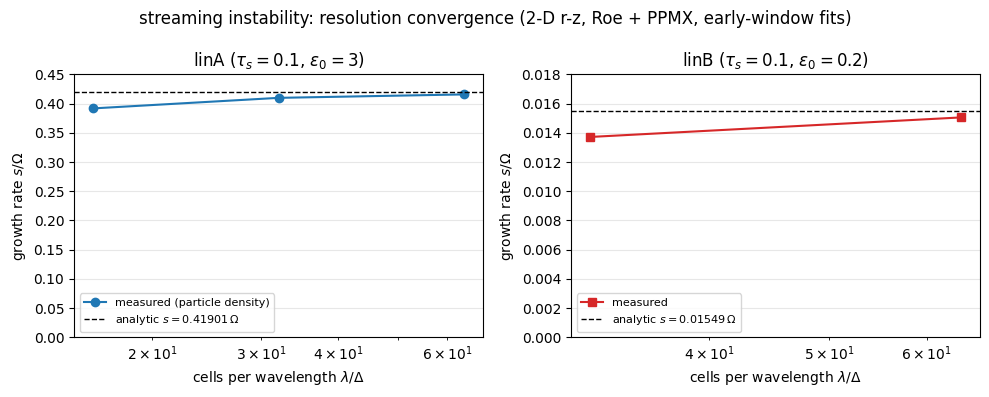

PASS  linA growth rate increases monotonically with resolution
PASS  linA at 64 cells/wavelength within ~2% of analytic (ppmx)
PASS  linB at 64 cells/wavelength within ~5% of analytic (ppmx, t<=6 fit)
PASS  linB grows at 32 cells/wavelength (BS10 Athena: no growth at CFL=0.8)


In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
nA = [res[k][0] for k in res if k.startswith('linA')]
sA = [res[k][1] for k in res if k.startswith('linA')]
axs[0].semilogx(nA, sA, 'o-', label='measured (particle density)')
axs[0].axhline(0.4190091, color='k', ls='--', lw=1, label='analytic $s=0.41901\\,\\Omega$')
axs[0].set_title('linA ($\\tau_s{=}0.1$, $\\epsilon_0{=}3$)')
nB = [res[k][0] for k in res if k.startswith('linB')]
sB = [res[k][1] for k in res if k.startswith('linB')]
axs[1].semilogx(nB, sB, 's-', color='tab:red', label='measured')
axs[1].axhline(0.0154862, color='k', ls='--', lw=1, label='analytic $s=0.01549\\,\\Omega$')
axs[1].axhline(0, color='gray', lw=0.5)
axs[1].set_title('linB ($\\tau_s{=}0.1$, $\\epsilon_0{=}0.2$)')
axs[0].set_ylim(0, 0.45)
axs[1].set_ylim(0, 0.018)
for ax in axs:
    ax.set_xlabel('cells per wavelength $\\lambda/\\Delta$')
    ax.set_ylabel('growth rate $s/\\Omega$')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('streaming instability: resolution convergence (2-D r-z, Roe + PPMX, early-window fits)')
plt.tight_layout(); plt.savefig(WORK/'si_convergence.png', dpi=150)
plt.show()

sA_sorted = [s for _, s in sorted((res[k] for k in res if k.startswith('linA')))]
ok &= verdict(all(np.diff(sA_sorted) > 0), 'linA growth rate increases monotonically with resolution')
s64 = [res[k][1] for k in res if k.startswith('linA') and res[k][0]==64][0]
ok &= verdict(0.40 < s64 < 0.43, 'linA at 64 cells/wavelength within ~2% of analytic (ppmx)')
sB64 = [res[k][1] for k in res if k.startswith('linB') and res[k][0]==64][0]
ok &= verdict(0.0140 < sB64 < 0.0165, 'linB at 64 cells/wavelength within ~5% of analytic (ppmx, t<=6 fit)')
sB32 = [res[k][1] for k in res if k.startswith('linB') and res[k][0]==32][0]
ok &= verdict(sB32 > 0.012, 'linB grows at 32 cells/wavelength (BS10 Athena: no growth at CFL=0.8)')

**Reading the convergence plot** (compare Bai & Stone 2010 Fig. streaming_grow1/2, at
CFL=0.8: linA $\approx$0.21–0.27/0.38/0.41 at 16/32/64 cpw; linB: no growth at 32,
$\approx$0.013 at 64): with `ppmx` this module **matches or exceeds Athena-PPM at every
resolution** for both modes. linB at 32 cpw grows here where Athena's CFL=0.8 run does
not. The measured rates are fit over the early clean window ($t\le6$ for linB): at 64+
cpw, round-off-seeded parasitic SI modes with $s\sim0.3$–$0.45\Omega$ can overtake the
slow linB fundamental at $t\gtrsim10$ (their takeover time is bit-sensitive — identical
physics across two builds gave $t\approx15$ vs clean-to-$t=40$), which is what
invalidated this notebook's original long-window linB fits (decay at 32, 0.0073 at 64 —
those numbers were measurements of the parasite soup, not the mode).

## 3. Solver requirements discovered in this phase

1. **Riemann solver: use `roe` for streaming-instability work.** With HLLE the
   asymptotic discrete growth rate at 32 cells/wavelength is $s \approx 0.075$ instead
   of $\approx 0.33$ — the mode's contact-like structure is diffused away. All damping/
   wave/NSH tests are insensitive (uniform or well-resolved fields).
2. **Reconstruction: use `ppmx` (`nghost ≥ 3`) for SI work.** PLM at marginal
   resolution damps the modes strongly (linA: 0.14/0.32/0.40 vs ppmx 0.39/0.41/0.42
   at 16/32/64 cpw); the dust module itself needs only `nghost ≥ 2`.
3. **CFL ≤ 0.45.** The imex2+ tableau advances stage-1 fluxes by
   $\gamma\Delta t = 1.71\Delta t$; gas stability requires a Courant number
   $\lesssim 0.58$ (Krapp et al. 2024 §2.2). At CFL = 0.9 the gas is violently unstable.
4. **Growth-rate measurement hygiene**: seed the exact eigenmode, quiet start
   (ppc = Npar² subcell lattice for ppc>1), fit the early window only ($t\le6$,
   classic-Athena practice from `streaming2d_single.c`).

## 4. 3-D shear-periodic machinery: status

Implemented in this phase (all serial-validated):
- **Particle shear wrap**: particles crossing the radial mesh boundaries are shifted
  azimuthally by the folded shear offset (positions and RK registers only — velocities
  are shear-relative, YJ16 Eq. 35), in `bvals_part.cpp`.
- **Boundary routing maps**: a shear-shifted particle generally lands in a different
  azimuthal MeshBlock than the plain x1-neighbor, so destination GID/rank come from
  (side, lx3, lx2) lookup maps built from the logical-location table (`bvals.cpp`).
- **$u^*$ shear remap**: the provisional gas velocity's radial ghost zones are remapped
  azimuthally each stage via a dedicated `ShearingBoxCC` instance (`dust_tasks.cpp`).

Serial 3-D NSH with shear-periodic boundaries runs 10 orbits cleanly with many boundary
crossings; the equilibrium holds to ~1e-4 — a **physical particle-noise floor** (the
background shear drifts particle columns apart azimuthally, so the lattice's deposits
are no longer exactly uniform; the 2-D round-off exactness is special to a rigid
lattice). The deviations oscillate with no secular drift.

**MPI status — FIXED (2026-07-15):** 3-D + MPI + shearing box initially crashed near
the first cross-rank particle migration. Root cause: the migration send list was sized
at 10% of the rank's particle count with an *unchecked* atomic append; in a shearing
box, coherent particle sheets (lattice columns sharing identical drift) cross block
faces simultaneously — far more than 10% in one stage — overflowing the buffer and
corrupting the heap. Fixed by sizing the list for the worst case (`bvals_part.cpp`).
After the fix: the repro runs clean; the 3-D shear NSH holds on 4 ranks at the serial
noise floor; a migration-heavy 3-D test agrees serial == MPI to every digit.

In [6]:
print('='*60)
print('OVERALL:', 'ALL CHECKS PASSED' if ok else 'SOME CHECKS FAILED - see above')
print('='*60)

OVERALL: ALL CHECKS PASSED
